# RNN

RNN (Recurrent Neural Network) is a type of neural network that processes sequential data by remembering information from previous steps.

In [51]:
import os
import numpy as np
import tensorflow as tf
import kagglehub

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout


#### Download Dataset

In [52]:
path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [53]:
import os

os.listdir(path)

['Training', 'Testing']

In [54]:
train_dir = os.path.join(path, "Training")
test_dir = os.path.join(path, "Testing")

print("Training:", train_dir)
print("Testing:", test_dir)


Training: /kaggle/input/brain-tumor-mri-dataset/Training
Testing: /kaggle/input/brain-tumor-mri-dataset/Testing


In [55]:
IMG_SIZE = 64
BATCH_SIZE = 32


## Tensorflow Image Generator

In [56]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)


In [57]:

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="training",
    shuffle=True
)


validation_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="validation",
    shuffle=False
)


print(train_generator.class_indices)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [58]:
model = Sequential([

    # Image:
    # 64 × 64 × 3
    #
    # RNN input:
    # 64 time steps × 192 features

    SimpleRNN(
        128,
        input_shape=(IMG_SIZE, IMG_SIZE * 3),
        return_sequences=True
    ),

    Dropout(0.3),

    SimpleRNN(
        64
    ),

    Dropout(0.3),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        4,
        activation="softmax"
    )
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


In [60]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,860 (226.02 KB)

 Trainable params: 57,860 (226.02 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
def prepare_batch(images, labels):

    # Original:
    # (batch, 64, 64, 3)

    # RNN:
    # (batch, 64, 192)

    images = tf.reshape(
        images,
        [-1, IMG_SIZE, IMG_SIZE * 3]
    )

    return images, labels

In [62]:
train_ds = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=(
        tf.TensorSpec(
            shape=(None, IMG_SIZE, IMG_SIZE, 3),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(None,),
            dtype=tf.float32
        )
    )
).map(
    prepare_batch
)

validation_ds = tf.data.Dataset.from_generator(
    lambda: validation_generator,
    output_signature=(
        tf.TensorSpec(
            shape=(None, IMG_SIZE, IMG_SIZE, 3),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(None,),
            dtype=tf.float32
        )
    )
).map(
    prepare_batch
)


In [63]:
history = model.fit(

    train_ds,

    steps_per_epoch=len(train_generator),

    validation_data=validation_ds,

    validation_steps=len(validation_generator),

    epochs=15
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.4511 - loss: 1.2362 - val_accuracy: 0.5723 - val_loss: 0.9786
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.5690 - loss: 1.0381 - val_accuracy: 0.6357 - val_loss: 0.8989
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.6404 - loss: 0.9147 - val_accuracy: 0.6857 - val_loss: 0.8142
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.6766 - loss: 0.8060 - val_accuracy: 0.6938 - val_loss: 0.7491
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.6996 - loss: 0.7767 - val_accuracy: 0.7152 - val_loss: 0.7048
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.7132 - loss: 0.7295 - val_accuracy: 0.7286 - val_loss: 0.6770
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.7286 - loss: 0.6900 - val_accuracy: 0.6652 - val_loss: 0.7998
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.7415 - loss: 0.6661 -

In [64]:
print(history.history["accuracy"])
print(history.history["val_accuracy"])

[0.45111608505249023, 0.5689732432365417, 0.6404017806053162, 0.676562488079071, 0.6995535492897034, 0.7131696343421936, 0.7285714149475098, 0.7415178418159485, 0.7513392567634583, 0.7540178298950195, 0.7669642567634583, 0.7691964507102966, 0.7997767925262451, 0.792187511920929, 0.8017857074737549]
[0.5723214149475098, 0.6357142925262451, 0.6857143044471741, 0.6937500238418579, 0.7151785492897034, 0.7285714149475098, 0.6651785969734192, 0.7482143044471741, 0.7303571701049805, 0.7544642686843872, 0.7232142686843872, 0.7339285612106323, 0.7410714030265808, 0.7464285492897034, 0.7669642567634583]


### Save Model

In [65]:
model.save("brain_tumor_rnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [66]:
from tensorflow.keras.models import load_model

model = load_model("brain_tumor_rnn.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [67]:
class_names = [
    name
    for name, index in sorted(
        train_generator.class_indices.items(),
        key=lambda x: x[1]
    )
]

print("Class names:", class_names)

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


Before reshape: (1, 64, 64, 3)
After reshape: (1, 64, 192)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted index: 3
Prediction: pituitary
Confidence: 84.87%


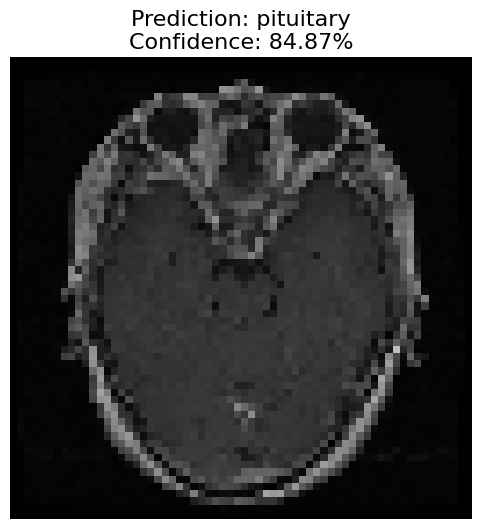

In [72]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

IMG_SIZE = 64

# Change this to your image
img_path = "Te-pi_108.jpg"

# Load image
img = image.load_img(
    img_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

# Convert to NumPy
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(
    img_array,
    axis=0
)

print("Before reshape:", img_array.shape)

img_array = img_array.reshape(
    1,
    64,
    64 * 3
)

print("After reshape:", img_array.shape)

# Prediction
prediction = model.predict(img_array)


predicted_index = np.argmax(
    prediction[0]
)

print("Predicted index:", predicted_index)

predicted_class = class_names[
    predicted_index
]

confidence = (
    prediction[0][predicted_index] * 100
)


print("Prediction:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")


plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=16
)

plt.axis("off")

plt.show()